In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**SPLIT DATASET**

In [2]:
import os
import shutil
import random

roi_path = "/content/drive/MyDrive/PCB_PROJECT/outputs/roi_images"

dataset_path = "/content/drive/MyDrive/PCB_PROJECT/dataset"

train_path = os.path.join(dataset_path,"train")
val_path = os.path.join(dataset_path,"val")
test_path = os.path.join(dataset_path,"test")

for path in [train_path,val_path,test_path]:
    os.makedirs(path,exist_ok=True)

for defect_class in os.listdir(roi_path):

    class_path = os.path.join(roi_path,defect_class)

    images = os.listdir(class_path)

    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split = int(0.85 * len(images))

    train_imgs = images[:train_split]
    val_imgs = images[train_split:val_split]
    test_imgs = images[val_split:]

    for folder in [train_path,val_path,test_path]:
        os.makedirs(os.path.join(folder,defect_class),exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(train_path,defect_class,img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(val_path,defect_class,img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(test_path,defect_class,img)
        )

print("Dataset split completed")

Dataset split completed


CHECK IMAGES IN EACH SPLIT

In [3]:
for split in ["train","val","test"]:
    print(split)
    path = f"/content/drive/MyDrive/PCB_PROJECT/dataset/{split}"

    for c in os.listdir(path):
        print(c,len(os.listdir(os.path.join(path,c))))

    print()

train
Spurious_copper 352
Spur 341
Short 343
Open_circuit 337
Missing_hole 347
Mouse_bite 344

val
Spurious_copper 75
Spur 73
Short 74
Open_circuit 72
Missing_hole 75
Mouse_bite 74

test
Spurious_copper 76
Spur 74
Short 74
Open_circuit 73
Missing_hole 75
Mouse_bite 74



**MODEL TRAINING**

In [2]:
!pip install timm

In [3]:
import torch
import torchvision
import timm

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
print(torch.__version__)

2.10.0+cu128


In [5]:
import torch
print(torch.cuda.is_available())

True


DATA PREPROCESS AND AUGUMENTATION

In [6]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [7]:
print(train_transforms)

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)


LOAD DATASET

In [8]:
dataset_path = "/content/drive/MyDrive/PCB_PROJECT/dataset"

train_dataset = datasets.ImageFolder(
    dataset_path + "/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    dataset_path + "/val",
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    dataset_path + "/test",
    transform=val_transforms
)

In [9]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))
print(train_dataset.classes)

2064
443
446
['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


CREATE DATALOADERS

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

torch.Size([16, 3, 128, 128])
tensor([3, 3, 2, 4, 3, 5, 2, 0, 3, 5])


LOAD EFFICIENTNET MODEL

In [13]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=6
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


DEFINE LOSS AND OPTIMIZER FUNCTION

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [16]:
print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


**TRAINING LOOP**

In [17]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")
    print("-----------------------------")

Epoch 1/10
Train Loss: 2.1872
Validation Accuracy: 66.59%
-----------------------------
Epoch 2/10
Train Loss: 0.8201
Validation Accuracy: 80.14%
-----------------------------
Epoch 3/10
Train Loss: 0.4122
Validation Accuracy: 88.26%
-----------------------------
Epoch 4/10
Train Loss: 0.3020
Validation Accuracy: 91.65%
-----------------------------
Epoch 5/10
Train Loss: 0.1674
Validation Accuracy: 93.23%
-----------------------------
Epoch 6/10
Train Loss: 0.1461
Validation Accuracy: 94.13%
-----------------------------
Epoch 7/10
Train Loss: 0.1107
Validation Accuracy: 95.71%
-----------------------------
Epoch 8/10
Train Loss: 0.0613
Validation Accuracy: 95.49%
-----------------------------
Epoch 9/10
Train Loss: 0.0553
Validation Accuracy: 95.26%
-----------------------------
Epoch 10/10
Train Loss: 0.0424
Validation Accuracy: 95.94%
-----------------------------


TEST SET EVALUATION

In [22]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 96.8609865470852


CONFUSION MATRIX

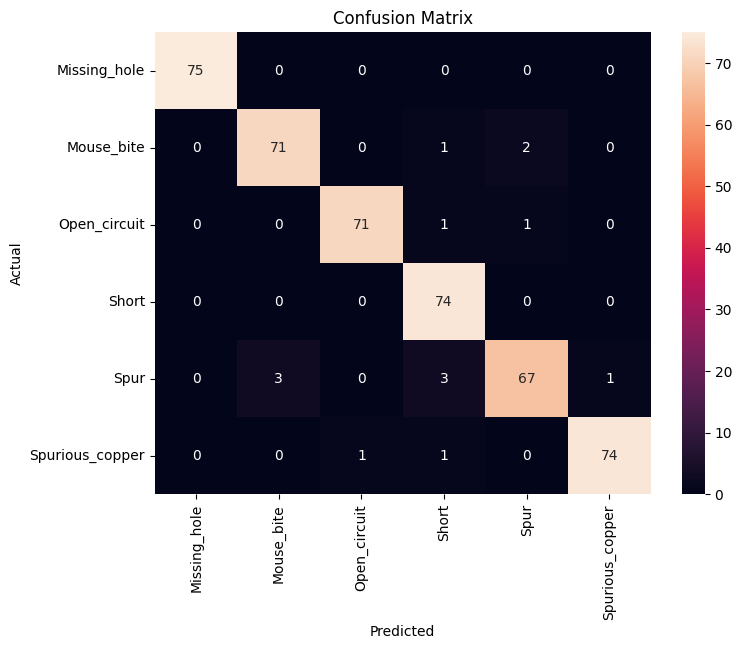

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**SAVE THE TRAINED MODEL**

In [24]:
model_path = "/content/drive/MyDrive/PCB_PROJECT/pcb_defect_model.pth"

torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/PCB_PROJECT/pcb_defect_model.pth


TO IMPROVE TEST ACCURACY

In [21]:
num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    print("Epoch", epoch+1)
    print("Train Loss:", train_loss)

Epoch 1
Train Loss: 0.06233043568234759
Epoch 2
Train Loss: 0.035446027396426154
Epoch 3
Train Loss: 0.02840624765077132
